In [1]:
pip install numpy torch torchvision matplotlib pillow ipython

Note: you may need to restart the kernel to use updated packages.


In [2]:
import csv
import numpy as np
from typing import Set,Tuple, List
import torch
import torch.utils
import torch.utils.data
import torch.nn as nn
import torchvision
NoneType = type(None)
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from PIL import Image
import torchvision.transforms.functional as TF
from torchvision.models import vgg11
from torchvision.models import mobilenet_v2
import torchvision.transforms as transforms
import time


<h1 id="exercise-1"><strong>Exercise 1</strong></h1>


<font size="4px"><p>This method returns the fruit name by getting the string at a specific index of the set.</p>
<dl>
<dt>param fruit_id</dt>
<dd><p>The id of the fruit to get</p>
</dd>
<dt>param fruits</dt>
<dd><p>The set of fruits to choose the id from</p>
</dd>
<dt>return</dt>
<dd><p>The string corrosponding to the index <code>fruit_id</code></p>
</dd>
</dl>
<p><strong>This method is part of a series of debugging exercises.</strong> <strong>Each Python method of this series contains bug that needs to be found.</strong></p>
<div class="line-block"><code>1   It does not print the fruit at the correct index, why is the returned result wrong?</code><br />
<code>2   How could this be fixed?</code></div>
<p>This example demonstrates the issue: name1, name3 and name4 are expected to correspond to the strings at the indices 1, 3, and 4: 'orange', 'kiwi' and 'strawberry'..</p>
</font>

**Solution**


The returned result is incorrect because
the method iterates over a set.
In Python, a set is unordered, meaning its
elements do not have a fixed or predictable order.
Therefore, accessing an element by an index while
iterating over a set will not consistently return
the expected fruit, since the iteration order can 
change every time the program runs.
so
we can Replace the set with a list

the input should have been a List (using square brackets []) to maintain the required order for indexing.

In [ ]:
# Previous Code

from typing import Set
def id_to_fruit(fruit_id: int, fruits: Set[str]) -> str:    
    idx = 0    
    for fruit in fruits:  
        import pdb; pdb.set_trace()
        if fruit_id == idx:
            return fruit
        idx += 1

name1 = id_to_fruit(1, {"apple", "orange", "melon", "kiwi", "strawberry"})
name3 = id_to_fruit(3, {"apple", "orange", "melon", "kiwi", "strawberry"})
name4 = id_to_fruit(4, {"apple", "orange", "melon", "kiwi", "strawberry"})

name1

> c:\users\farhadi\appdata\local\temp\ipykernel_16628\3926536175.py(7)id_to_fruit()



<p><strong> During debugging,  </strong>
    
I noticed that the function relied on indexing, but the input collection was a set, which is unordered in Python.

By stepping through the loop in the debugger, I observed that the same index returned different fruits—for example, 
index 1 returned strawberry, which was incorrect.

This made it clear that a list was the correct data structure, since it preserves order.

In [ ]:
# New Code

def id_to_fruit(fruit_id: int, fruits: list[str]) -> str:
    idx = 0
    for fruit in fruits:   
        if fruit_id == idx:
            return fruit
        idx += 1

    raise RuntimeError(f"Fruit with id {fruit_id} does not exist")

In [ ]:
# name1 = id_to_fruit(1, {"apple", "orange", "melon", "kiwi", "strawberry"})
# name3 = id_to_fruit(3, {"apple", "orange", "melon", "kiwi", "strawberry"})
# name4 = id_to_fruit(4, {"apple", "orange", "melon", "kiwi", "strawberry"})


In [ ]:
# Fixed Inputs: Using List (square brackets []) instead of Set (curly braces {})
name1 = id_to_fruit(1, ["apple", "orange", "melon", "kiwi", "strawberry"])
name3 = id_to_fruit(3, ["apple", "orange", "melon", "kiwi", "strawberry"])
name4 = id_to_fruit(4, ["apple", "orange", "melon", "kiwi", "strawberry"])

# Expected results:
# name1 is 'orange' (index 1)
# name3 is 'kiwi' (index 3)
# name4 is 'strawberry' (index 4)

In [ ]:
name1

<h1 id="exercise-2"><strong>Exercise 2</strong></h1>


<font size="4px"><p>This method will flip the x and y coordinates in the coords array.</p>
<dl>
<dt>param coords</dt>
<dd><p>A numpy array of bounding box coordinates with shape [n,5] in format: :</p>
<pre><code>[[x11, y11, x12, y12, classid1],
 [x21, y21, x22, y22, classid2],
 ...
 [xn1, yn1, xn2, yn2, classid3]]</code></pre>
</dd>
<dt>return</dt>
<dd><p>The new numpy array where the x and y coordinates are flipped.</p>
</dd>
</dl>
<p><strong>This method is part of a series of debugging exercises.</strong> <strong>Each Python method of this series contains bug that needs to be found.</strong></p>
<div class="line-block"><code>1   Can you spot the obvious error?</code><br />
<code>2   After fixing the obvious error it is still wrong, how can this be fixed?</code></div>
</font>

<font size="4px"><p>The example demonstrates the issue. The returned swapped_coords are expected to have swapped x and y coordinates in each of the rows.</p>
</font>

<p><strong>Mistakes :</p></strong>

Mistake 1: The columns are assigned
incorrectly (coords[:,1] is repeated).

Mistake 2: In this operation, **columns 2 and 3 were supposed to be swapped**,  
but this did **not** happen as expected. 
Without copy() or advanced indexing,
numpy may overwrite values unexpectedly.


<p><strong>Explanation of Steps:</p></strong>

1- RHS values are captured from the original array.

2- assignments happen on the original array (LHS), and some updates override subsequent assignments in simultaneous multi-column assignment.

3- this is why row[3] becomes 6 (from updated column 2) instead of 15.
<div class="line-block"><code>input [10  5 15  6  0] 
coords[:, 0], coords[:, 1], coords[:, 2], coords[:, 3], = coords[:, 1], coords[:, 1], coords[:, 3], coords[:, 2]
output[ 5  5  6  6  0]
</code><br />


now we can see :  row[3] updated (intended 15, but row[2] was already 6) |

| Step | Description                                      | row (current values) | Notes                                                  |
| ---- | ------------------------------------------------ | -------------------- | ------------------------------------------------------ |
| 0    | Original row                                     | [10  5  15  6]       | input row                                              |
| 1    | Evaluate RHS: `[row[1], row[1], row[3], row[2]]` | temp = [5  5  6  15] | RHS created from original row                          |
| 2    | Assign row[0] = temp[0]                          | [5  5  15  6]        | row[0] updated                                         |
| 3    | Assign row[1] = temp[1]                          | [5  5  15  6]        | row[1] updated                                         |
| 4    | Assign row[2] = temp[2]                          | [5  5  6  6]         | row[2] updated (was 15 → 6)                            |
| 5    | Assign row[3] = temp[3]                          | [5  5  6  6]         | row[3] updated (intended 15, but row[2] was already 6) |

**Solution**

temp0 = coords[:, 0].copy()

temp1 = coords[:, 1].copy()

temp2 = coords[:, 2].copy()

temp3 = coords[:, 3].copy()


coords[:, 0] = temp1

coords[:, 1] = temp1

coords[:, 2] = temp3

coords[:, 3] = temp2

**Or**


 coords = coords.copy() 
 
 coords[:, [0, 1, 2, 3]] = coords[:, [1, 0, 3, 2]] 

This prevents in-place overwriting and guarantees a correct column swap.

In [ ]:
# Previous Code ith print debugging

# Example data
import numpy as np
coords = np.array([[10, 5, 15, 6, 0],
                   [11, 3, 13, 6, 0],
                   [5, 3, 13, 6, 1],
                   [4, 4, 13, 6, 1],
                   [6, 5, 13, 16, 1]])

# Step 1: Print original array
print("Original coords:")
print(coords)

#Buggy Function
import numpy as np
def swap(coords: np.ndarray):   
    coords[:, 0], coords[:, 1], coords[:, 2], coords[:, 3], = coords[:, 1], coords[:, 1], coords[:, 3], coords[:, 2]
    return coords

# Step 2: Attempt swap using the buggy function
swapped_coords = swap(coords)
print("\nSwapped coords (attempted):")
print(swapped_coords)


In [ ]:
# New Code
def swap(coords: np.ndarray):
    """
    Swap x and y coordinates in a bounding box array of shape [n,5].
    """
    coords = coords.copy()  #  avoid modifying original array
    coords[:, [0, 1, 2, 3]] = coords[:, [1, 0, 3, 2]]  # correct swap
    return coords



In [ ]:
import numpy as np
coords = np.array([[10, 5, 15, 6, 0],
                   [11, 3, 13, 6, 0],
                   [5, 3, 13, 6, 1],
                   [4, 4, 13, 6, 1],
                   [6, 5, 13, 16, 1]])
swapped_coords = swap(coords)

swapped_coords

<h1 id="exercise-3"><strong>Exercise 3</strong></h1>


<font size="4px"><p>This code plots the precision-recall curve based on data from a .csv file, where precision is on the x-axis and recall is on the y-axis. It it not so important right now what precision and recall means.</p>
<dl>
<dt>param csv_file_path</dt>
<dd><p>The CSV file containing the data to plot.</p>
</dd>
</dl>
<p><strong>This method is part of a series of debugging exercises.</strong> <strong>Each Python method of this series contains bug that needs to be found.</strong></p>
<div class="line-block"><code>1   For some reason the plot is not showing correctly, can you find out what is going wrong?</code><br />
<code>2   How could this be fixed?</code></div>
<p>This example demonstrates the issue. It first generates some data in a csv file format and the plots it using the <code>plot_data</code> method. If you manually check the coordinates and then check the plot, they do not correspond.</p>
</font>

In [9]:
import csv
import numpy as np
import matplotlib.pyplot as plt

def plot_data(csv_file_path: str):
    # load data
    results = []
    with open(csv_file_path) as result_csv:
        csv_reader = csv.reader(result_csv, delimiter=',')
        next(csv_reader)
        for row in csv_reader:
            results.append(row)
        results = np.stack(results)

    # plot precision-recall curve
    plt.plot(results[:, 1], results[:, 0])
    plt.ylim([-0.05, 1.05])
    plt.xlim([-0.05, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.show()


f = open("data_file.csv", "w")
w = csv.writer(f)
_ = w.writerow(["precision", "recall"])
w.writerows([[0.013,0.951],
             [0.376,0.851],
             [0.441,0.839],
             [0.570,0.758],
             [0.635,0.674],
             [0.721,0.604],
             [0.837,0.531],
             [0.860,0.453],
             [0.962,0.348],
             [0.982,0.273],
             [1.0,0.0]])
f.close()
plot_data('data_file.csv')


ValueError: all input arrays must have the same shape

**Solution**

Mistake : 
CSV rows were appended as strings 
(["0.376","0.851"]). np.stack kept non-numeric data,
 so plotting used text instead of numbers.

 Precision and recall are plotted in the wrong order

Fix: Convert each value to float when appending 
([float(row[0]), float(row[1])]) and use np.array(results) 
so results is a numeric array. The rest of the code 
(variable names, plotting lines) is unchanged.

In [ ]:
import csv
import numpy as np
import matplotlib.pyplot as plt

def plot_data(csv_file_path: str):
    """
    Load CSV data and plot Precision-Recall curve.
    
    Debug note: Original code used np.stack on string lists, which caused
    ValueError. Fixed by converting strings to float and using np.array.
    """
    results = []
    with open(csv_file_path, newline='') as result_csv:
        csv_reader = csv.reader(result_csv, delimiter=',')
        next(csv_reader)  # skip header
        
        for row in csv_reader:
            if len(row) < 2:  # skip empty or invalid rows
                continue
            # convert strings to floats
            results.append([float(row[0]), float(row[1])])
    
    results = np.array(results)  # convert to numeric 2D array

    # plot Precision-Recall curve
    plt.plot(results[:, 0], results[:, 1], marker='o', linestyle='-')  # x = Recall, y = Precision
    plt.ylim([-0.05, 1.05])
    plt.xlim([-0.05, 1.05])
    plt.xlabel('Precision')
    plt.ylabel('Recall')
    plt.title('Precision–Recall Curve')
    plt.grid(True)
    plt.show()


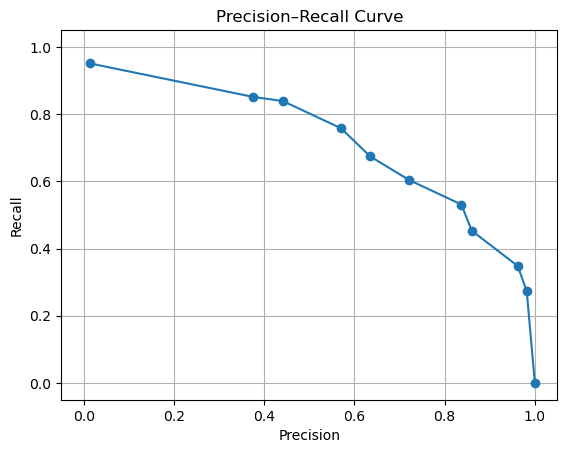

In [8]:
f = open("data_file.csv", "w")
w = csv.writer(f)
_ = w.writerow(["precision", "recall"])
w.writerows([[0.013,0.951],
             [0.376,0.851],
             [0.441,0.839],
             [0.570,0.758],
             [0.635,0.674],
             [0.721,0.604],
             [0.837,0.531],
             [0.860,0.453],
             [0.962,0.348],
             [0.982,0.273],
             [1.0,0.0]])
f.close()
plot_data('data_file.csv')


<h1 id="generator-for-exercise-4">** Generator (for Exercise 4)**</h1>


<font size="4px"><p>Generator class for the GAN</p>
</font>

In [ ]:
# You can copy this code to your personal pipeline project or execute it here.
class Generator(nn.Module):
    """
    Generator class for the GAN
    """

    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 784),
            nn.Tanh(),
        )

    def forward(self, x):
        output = self.model(x)
        output = output.view(x.size(0), 1, 28, 28)
        return output



<h1 id="discriminator-for-exercise-4">** Discriminator (for Exercise 4)**</h1>


<font size="4px"><p>Discriminator class for the GAN</p>
</font>

In [ ]:
# You can copy this code to your personal pipeline project or execute it here.
class Discriminator(nn.Module):
    """
    Discriminator class for the GAN
    """
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.view(x.size(0), 784)
        output = self.model(x)
        return output



<h1 id="exercise-4">** Exercise 4**</h1>


<font size="4px"><p>The method trains a Generative Adversarial Network and is based on: <a href="https://realpython.com/generative-adversarial-networks/">https://realpython.com/generative-adversarial-networks/</a></p>
<p>The Generator network tries to generate convincing images of handwritten digits. The Discriminator needs to detect if the image was created by the Generater or if the image is a real image from a known dataset (MNIST). If both the Generator and the Discriminator are optimized, the Generator is able to create images that are difficult to distinguish from real images. This is goal of a GAN.</p>
<p>This code produces the expected results at first attempt at about 50 epochs.</p>
<dl>
<dt>param batch_size</dt>
<dd><p>The number of images to train in one epoch.</p>
</dd>
<dt>param num_epochs</dt>
<dd><p>The number of epochs to train the gan.</p>
</dd>
<dt>param device</dt>
<dd><p>The computing device to use. If CUDA is installed and working then <span class="title-ref">cuda:0</span> is chosen otherwise 'cpu' is chosen. Note: Training a GAN on the CPU is very slow.</p>
</dd>
</dl>
<p><strong>This method is part of a series of debugging exercises.</strong> <strong>Each Python method of this series contains bug that needs to be found.</strong></p>
<p>It contains at least two bugs: one structural bug and one cosmetic bug. Both bugs are from the original tutorial.</p>
<div class="line-block"><code>1   Changing the batch_size from 32 to 64 triggers the structural bug.</code><br />
<code>2   Can you also spot the cosmetic bug?</code><br />
<code>Note: to fix this bug a thorough understanding of GANs is not necessary.</code></div>
<p>Change the batch size to 64 to trigger the bug with message: ValueError: "Using a target size (torch.Size([128, 1])) that is different to the input size (torch.Size([96, 1])) is deprecated. Please ensure they have the same size."</p>
</font>

# **Solution**

**use the actual size of the current real_samples tensor to correctly dimension the label tensors. The size of the batch is real_samples.size(0)**


# Cosmetic 
**Corrected: Check if this is the last batch of the current epoch.**

**if n == len(train_loader) - 1:**


call tight_layout() before suptitle(). This can make the title overlap with the images.

Fix: put suptitle() after tight_layout() and move it a little higher:



cmap="gray_r", which reverses the colors. 
Usually cmap="gray" looks better.


In [ ]:
# You can copy this code to your personal pipeline project or execute it here.
def train_gan(batch_size: int = 32, num_epochs: int = 100, device: str = "cuda:0" if torch.cuda.is_available() else "cpu"):
    
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

    try:
        train_set = torchvision.datasets.MNIST(root=".", train=True, download=True, transform=transform)
    except:
        print("Failed to download MNIST, retrying with different URL")
        # see: https://github.com/pytorch/vision/blob/master/torchvision/datasets/mnist.py
        torchvision.datasets.MNIST.resources = [
            ('https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz',
             'f68b3c2dcbeaaa9fbdd348bbdeb94873'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz',
             'd53e105ee54ea40749a09fcbcd1e9432'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz',
             '9fb629c4189551a2d022fa330f9573f3'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz',
             'ec29112dd5afa0611ce80d1b7f02629c')
        ]
        train_set = torchvision.datasets.MNIST(root=".", train=True, download=True, transform=transform)

    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)

    # example data
    real_samples, mnist_labels = next(iter(train_loader))

    fig = plt.figure()
    for i in range(16):
        sub = fig.add_subplot(4, 4, 1 + i)
        sub.imshow(real_samples[i].reshape(28, 28), cmap="gray_r")
        sub.axis('off')

    fig.tight_layout()
    fig.suptitle("Real images")
    display(fig)

    time.sleep(5)

    # Set up training
    discriminator = Discriminator().to(device)
    generator = Generator().to(device)
    lr = 0.0001
    loss_function = nn.BCELoss()
    optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
    optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

    # train
    for epoch in range(num_epochs):
        for n, (real_samples, mnist_labels) in enumerate(train_loader):

            # Corrected
            current_batch_size = real_samples.size(0) # Get the actual size of the current batch

            # Data for training the discriminator
            real_samples = real_samples.to(device=device)
            real_samples_labels = torch.ones((current_batch_size, 1)).to(device=device)
            latent_space_samples = torch.randn((current_batch_size, 100)).to(device=device)
            generated_samples = generator(latent_space_samples)
            generated_samples_labels = torch.zeros((current_batch_size, 1)).to(device=device)
            all_samples = torch.cat((real_samples, generated_samples))
            all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels))

            # Training the discriminator
            discriminator.zero_grad()
            output_discriminator = discriminator(all_samples)
            loss_discriminator = loss_function(output_discriminator, all_samples_labels)
            loss_discriminator.backward()
            optimizer_discriminator.step()

            # Data for training the generator
            latent_space_samples = torch.randn((current_batch_size, 100)).to(device=device)

            # Training the generator
            generator.zero_grad()
            generated_samples = generator(latent_space_samples)
            output_discriminator_generated = discriminator(generated_samples)
            loss_generator = loss_function(output_discriminator_generated, real_samples_labels)
            loss_generator.backward()
            optimizer_generator.step()

            # Show loss and samples generated
            if n == len(train_loader) - 1:
                name = f"Generate images\n Epoch: {epoch} Loss D.: {loss_discriminator:.2f} Loss G.: {loss_generator:.2f}"
                generated_samples = generated_samples.detach().cpu().numpy()
                fig = plt.figure()
                for i in range(16):
                    sub = fig.add_subplot(4, 4, 1 + i)
                    sub.imshow(generated_samples[i].reshape(28, 28), cmap="gray")
                    sub.axis('off')
                fig.tight_layout()
                fig.suptitle(name)
                clear_output(wait=False)
                display(fig)



In [ ]:
train_gan(batch_size=32, num_epochs=100)
